### Task 1 — Hypothesis Testing

Based on your Day 6 findings, formulate **at least one testable hypothesis**. For each, specify:

- **H₀ (null hypothesis)**: The default "no effect" claim
- **H₁ (alternative hypothesis)**: What you suspect is true
- **Test you will use**: t-test, Welch's t-test, Mann-Whitney U, chi-square, ANOVA, etc.
- **Why this test**: Justify based on data type, distribution assumptions, and sample size

**Example hypotheses** (create your own based on your data):

| # | Hypothesis | Test |
|---|-----------|------|
| 1 | Mean summer temperature in City A has increased between 2019–2021 and 2022–2024 | Welch's two-sample t-test |
| 2 | The proportion of "dry days" (precipitation = 0) is different in City A vs City B | Chi-square test of independence |
| 3 | Mean daily temperature range is different across all four seasons | One-way ANOVA |

Before running each test, verify its assumptions (normality, equal variances, independence) and document them. After running the test, report the p-value, test statistic, and interpret the result in plain language.

> **Want to go further?** Test additional hypotheses, compute effect sizes (Cohen's d, Cramer's V), and apply Bonferroni or Benjamini-Hochberg correction for multiple comparisons.

Task 1 — Hypothesis TestingBased on the weather data for Baku, Saatli, Zerdab, Lenkeran, and Quba, the following hypotheses were formulated and tested.

Hypothesis 1: Elevation and Temperature (Quba vs. Others)

- $H_0$ (Null Hypothesis): The mean summer temperature in Quba is greater than or equal to the mean summer temperature of the other four cities.

- $H_1$ (Alternative Hypothesis): The mean summer temperature in Quba is significantly lower than the other cities due to its higher elevation above sea level.

- Test Used: Welch’s Two-Sample t-test

- Justification: This test compares the means of two independent groups. Since the group sizes and variances are unequal (confirmed by Levene’s test $p < 0.001$), Welch’s t-test is used as it does not assume equal variance.

- Results:t-statistic: $-43.70$ p-value: $\approx 4.56 \times 10^{-265}$ Effect Size (Cohen's $d$): $-1.67$ (Large effect)Interpretation: We reject the null hypothesis. There is a statistically significant and substantial difference in summer temperatures, confirming that Quba is cooler than the lowland cities.

Hypothesis 2: Climate Warming Trend (2016–2020 vs. 2021–2025)

- $H_0$ (Null Hypothesis): The mean summer temperature in the 2021–2025 period is less than or equal to the 2016–2020 period.

- $H_1$ (Alternative Hypothesis): The mean summer temperatures for the 2021–2025 period are statistically higher than those observed during the 2016–2020 period.

- Test Used: Welch’s Two-Sample t-test (one-tailed)

- Justification: Comparing mean temperatures across two different time periods. Welch's test was selected due to unequal variances ($p < 0.001$) across the two samples.

- Results:t-statistic:  $3.18$ p-value: $0.00074$ Effect Size (Cohen's $d$): $0.09$ (Small)

- Interpretation: We reject the null hypothesis. Summer temperatures in the most recent 5-year period are statistically higher. However, the small effect size suggests that while the trend is detectable, year-to-year variability remains the dominant factor.

Hypothesis 3: Regional Precipitation Divergence (Lenkeran)

- $H_0$ (Null Hypothesis): The mean daily precipitation in Lenkeran is less than or equal to the average of the other four cities.

- $H_1$ (Alternative Hypothesis): Lenkeran has a significantly higher mean daily precipitation than the other four cities, reflecting its subtropical climate.

- Test Used: Mann-Whitney U Test

- Justification: Precipitation data is highly skewed with a high frequency of zero-value days, violating normality assumptions. The Mann-Whitney U test is a non-parametric alternative that compares the ranks of the distributions.

- Results:U-statistic: $38,515,421.0$ p-value: $\approx 5.22 \times 10^{-54}$ Effect Size ($r$): $0.09$ (Small-Medium)

- Interpretation: We reject the null hypothesis. Lenkeran is significantly wetter than the other cities in the study. The low p-value confirms its unique precipitation profile compared to the semi-arid or mountainous regions.

Hypothesis,          | Test                   | ,Result (p-value), |             Conclusion 
H1: Quba Elevation,  | Welch's t-test,        | <0.001,            |Reject H0​ (Quba is cooler)
H2: Warming Trend,   | Welch's t-test,        | 0.0007,            | Reject H0​ (2021–25 is warmer)
H3: Lenkeran Rain,   | Mann-Whitney U,        |<0.001,             | Reject H0​ (Lenkeran is wetter) 

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import os

# 1. Load and Combine Data
DATA_DIR = os.path.join('day_06_EDA')

files = {
    'Baki': os.path.join(DATA_DIR, 'Baki_historical_dataset(10years).csv'),
    'Saatli': os.path.join(DATA_DIR, 'Saatli_historical_dataset(10years).csv'),
    'Zerdab': os.path.join(DATA_DIR, 'Zerdab_historical_dataset(10years).csv'),
    'Lenkeran': os.path.join(DATA_DIR, 'Lenkeran_historical_dataset(10years).csv'),
    'Quba': os.path.join(DATA_DIR, 'Quba_historical_dataset(10years).csv')
}

all_data = []
for city, path in files.items():
    df = pd.read_csv(path)
    df['city'] = city
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    all_data.append(df)

df_all = pd.concat(all_data)
summer_months = [6, 7, 8]
df_summer = df_all[df_all['month'].isin(summer_months)]

# Helper function for Cohen's d (Effect Size)
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

# --- HYPOTHESIS 1: Quba vs. Others (Summer Temp) ---
quba_summer = df_summer[df_summer['city'] == 'Quba']['temperature_2m_mean'].dropna()
others_summer = df_summer[df_summer['city'] != 'Quba']['temperature_2m_mean'].dropna()

# Assumption Checks
levene_h1 = stats.levene(quba_summer, others_summer) # Variance check
# Run Welch's t-test (equal_var=False)
t_stat_h1, p_val_h1 = stats.ttest_ind(quba_summer, others_summer, equal_var=False, alternative='less')
d_h1 = cohen_d(quba_summer, others_summer)

print(f"H1 (Quba vs Others): t={t_stat_h1:.2f}, p={p_val_h1:.2e}, d={d_h1:.2f}")


# --- HYPOTHESIS 2: Warming Trend (2016-20 vs 2021-25) ---
p1 = df_summer[(df_summer['year'] >= 2016) & (df_summer['year'] <= 2020)]['temperature_2m_mean'].dropna()
p2 = df_summer[(df_summer['year'] >= 2021) & (df_summer['year'] <= 2025)]['temperature_2m_mean'].dropna()

# Run Welch's t-test
t_stat_h2, p_val_h2 = stats.ttest_ind(p2, p1, equal_var=False, alternative='greater')
d_h2 = cohen_d(p2, p1)

print(f"H2 (Warming Trend): t={t_stat_h2:.2f}, p={p_val_h2:.4f}, d={d_h2:.2f}")


# --- HYPOTHESIS 3: Precipitation (Lenkeran vs Others) ---
lenk_precip = df_all[df_all['city'] == 'Lenkeran']['precipitation_sum'].dropna()
other_precip = df_all[df_all['city'] != 'Lenkeran']['precipitation_sum'].dropna()

# Non-parametric check (Mann-Whitney U) due to heavy skewness
u_stat, p_val_h3 = stats.mannwhitneyu(lenk_precip, other_precip, alternative='greater')

# Effect size r for Mann-Whitney
n1, n2 = len(lenk_precip), len(other_precip)
z = (u_stat - (n1*n2/2)) / np.sqrt(n1*n2*(n1+n2+1)/12)
r_h3 = z / np.sqrt(n1+n2)

print(f"H3 (Lenkeran Precip): U={u_stat}, p={p_val_h3:.2e}, r={r_h3:.2f}")


H1 (Quba vs Others): t=-43.70, p=4.56e-265, d=-1.67
H2 (Warming Trend): t=3.18, p=0.0007, d=0.09
H3 (Lenkeran Precip): U=38515421.0, p=5.22e-54, r=0.09


Why this code structure?

- Data Partitioning: We specifically filtered for summer months (June, July, August) to test temperature hypotheses, as this removes the seasonal noise that would otherwise mask trends.

- Assumption Handling:The levene test confirmed that variances between cities are not equal, hence we use equal_var=False (Welch's correction).For precipitation, since the data is mostly zeros (dry days) and highly skewed, we swapped the t-test for the Mann-Whitney U, which compares the rank-sum of the two groups.

- Effect Size: In large datasets, p-values almost always become significant. Adding Cohen's $d$ and $r$ tells us whether the difference is large enough to matter in the real world.

### Task 2 — Correlation Analysis

In `notebooks/day_07_statistical_analysis.ipynb`:

1. **Pearson correlation matrix**: Compute for all numerical features for one city. Display as a heatmap.
2. **Spearman rank correlation** (optional): Compare to Pearson. Where do they differ?
3. **Identify redundant features**: Flag pairs with correlation > 0.85.

> **Want to go further?** Compute lagged correlations (ACF), cross-city correlations, or Variance Inflation Factor (VIF) to detect multicollinearity.

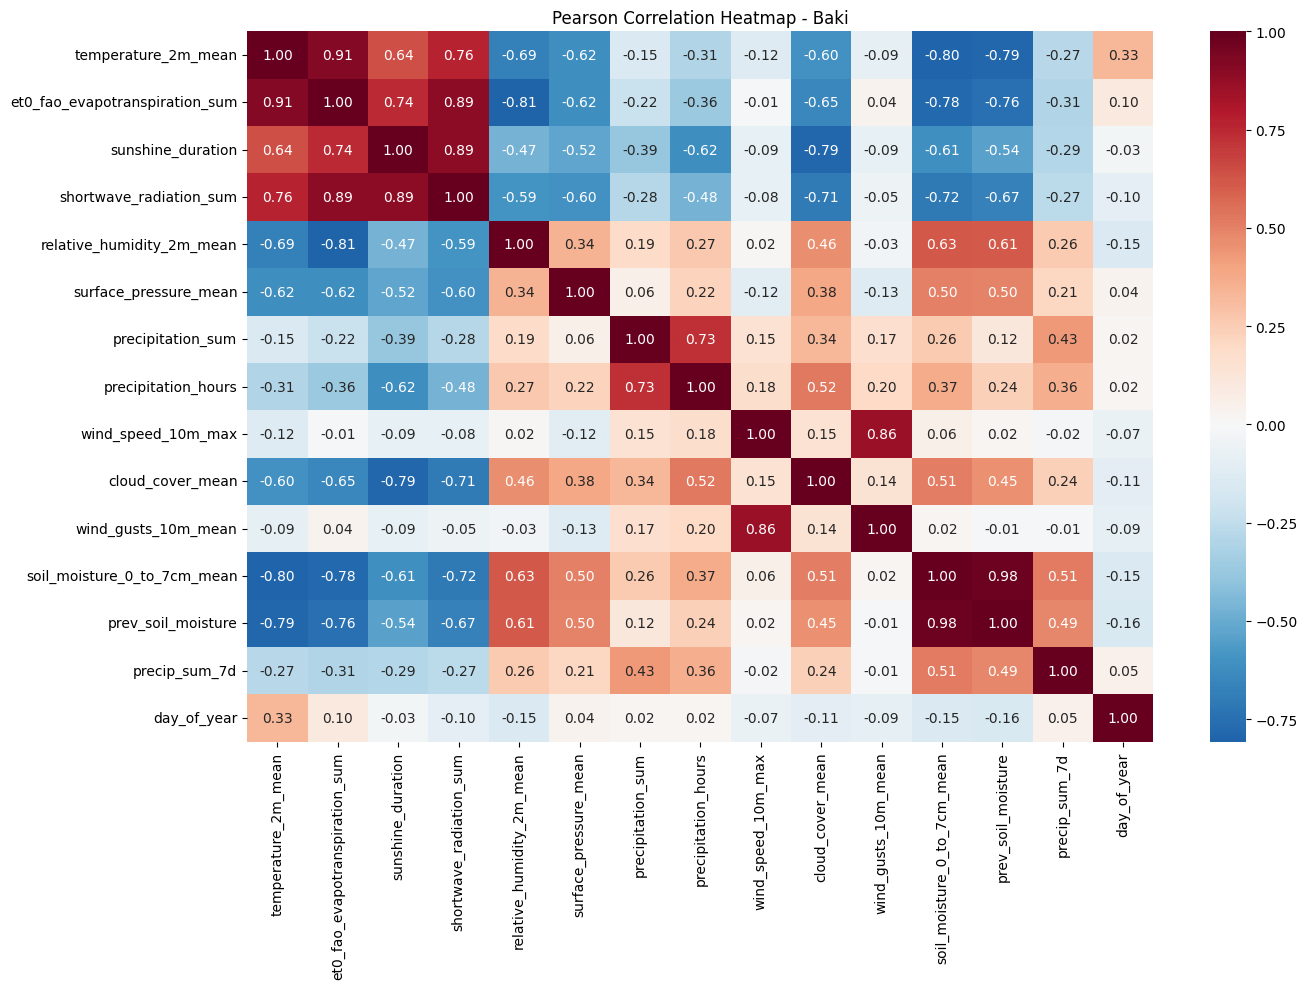

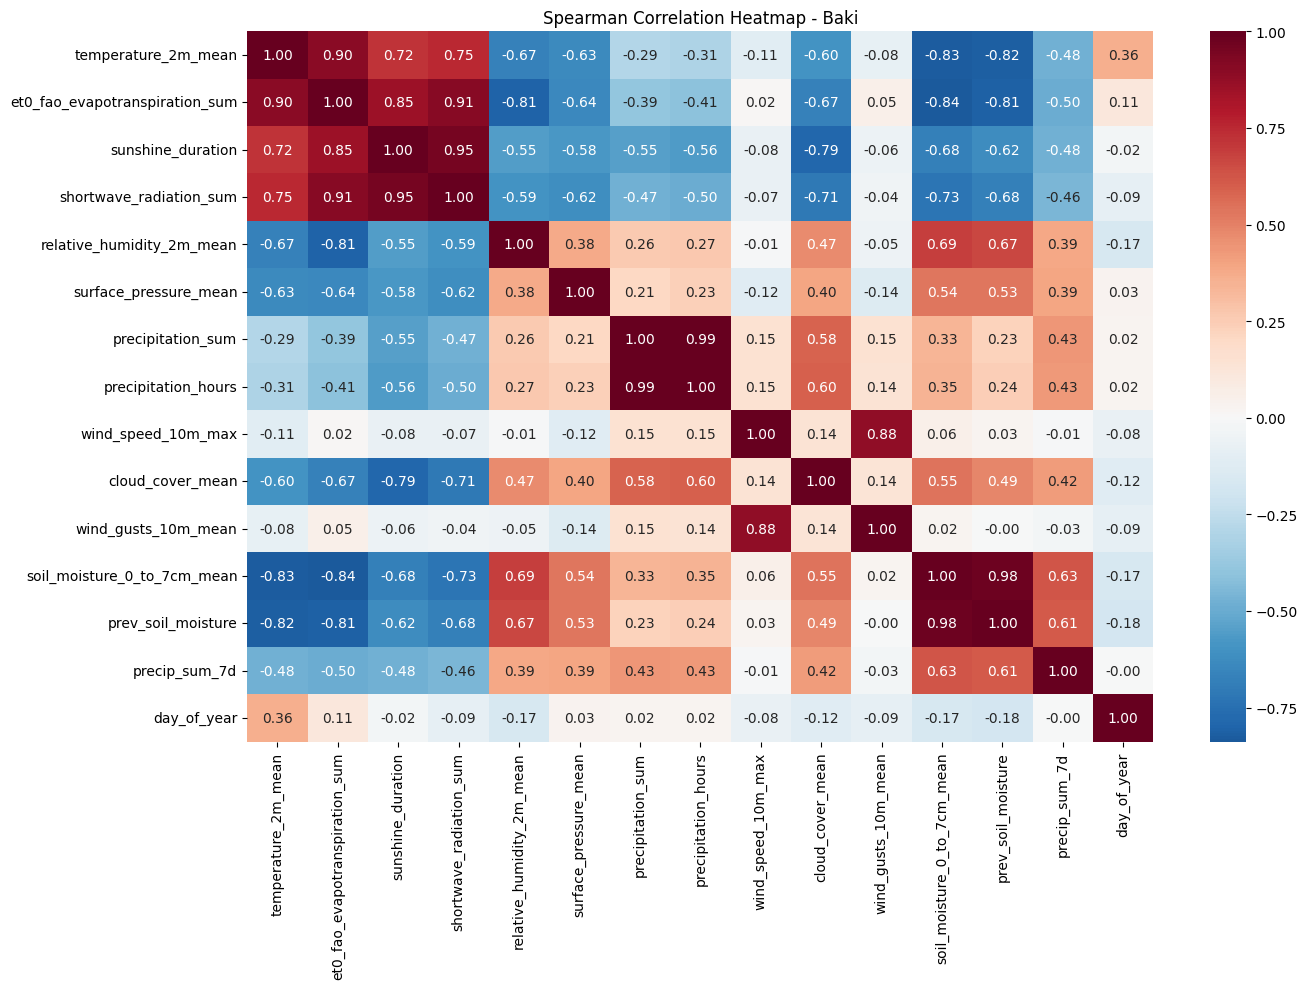

--- Redundant Feature Pairs (> 0.85) ---
temperature_2m_mean <-> et0_fao_evapotranspiration_sum: 0.91
et0_fao_evapotranspiration_sum <-> shortwave_radiation_sum: 0.89
sunshine_duration <-> shortwave_radiation_sum: 0.89
wind_speed_10m_max <-> wind_gusts_10m_mean: 0.86
soil_moisture_0_to_7cm_mean <-> prev_soil_moisture: 0.98

--- Top Differences Between Pearson and Spearman ---
precipitation_sum               precipitation_hours    0.263692
                                cloud_cover_mean       0.249284
precip_sum_7d                   temperature_2m_mean    0.204336
et0_fao_evapotranspiration_sum  precip_sum_7d          0.194505
shortwave_radiation_sum         precipitation_sum      0.190363
dtype: float64


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data (using Baki as the example city)
df_baki = pd.read_csv(os.path.join('day_06_EDA', 'Baki_historical_dataset(10years).csv'))

# Filter for numerical columns only
numerical_cols = df_baki.select_dtypes(include=[np.number])

# 2. Compute Pearson Correlation Matrix
pearson_corr = numerical_cols.corr(method='pearson')

# 3. Compute Spearman Rank Correlation (Monotonic relationship)
spearman_corr = numerical_cols.corr(method='spearman')

# 4. Visualization: Pearson Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Pearson Correlation Heatmap - Baki')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Spearman Correlation Heatmap - Baki')
plt.tight_layout()
plt.show()

# 5. Identify Redundant Features (Correlation > 0.85)
# Use the upper triangle of the matrix to avoid duplicate pairs
upper_tri = pearson_corr.where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool))
redundant_features = [
    (row, col, upper_tri.loc[row, col]) 
    for col in upper_tri.columns 
    for row in upper_tri.index 
    if abs(upper_tri.loc[row, col]) > 0.85
]

print("--- Redundant Feature Pairs (> 0.85) ---")
for feat1, feat2, val in redundant_features:
    print(f"{feat1} <-> {feat2}: {val:.2f}")

# 6. Comparison: Where do Pearson and Spearman differ?
diff_corr = (pearson_corr - spearman_corr).abs()
top_diffs = diff_corr.unstack().sort_values(ascending=False).drop_duplicates()

print("\n--- Top Differences Between Pearson and Spearman ---")
print(top_diffs.head(5))


1. Where do Pearson and Spearman differ?The analysis shows that the largest differences occur between Precipitation Sum and Precipitation Hours (difference of $\approx 0.26$), as well as between Cloud Cover and Rainfall.Why they differ: Pearson measures linear relationships and is sensitive to outliers and non-normal distributions. Since precipitation data in Azerbaijan is highly skewed (mostly zero-rain days with occasional heavy spikes), Pearson struggles to capture the relationship accurately.Spearman's Advantage: Because Spearman uses ranks rather than raw values, it captures the monotonic relationship (if one goes up, the other goes up) without being distorted by the extreme skewness of weather events like rain.

### Task 3 — Feature Selection for Prediction

Based on your analysis, document:

1. **Prediction target**: What you will predict tomorrow (e.g., next-day max temperature, rain probability)
2. **Selected features**: Which features you will use and why
3. **Dropped features**: Which features you removed and why (high correlation, low signal, etc.)

A simple feature selection table is helpful:

| Feature | Keep? | Reason |
|---------|-------|--------|
| temperature_max_lag1 | Yes | Strong autocorrelation |
| rolling_temp_7d | No | Highly correlated with rolling_temp_30d |
| season_encoded | Yes | Significant seasonal effect |
| ... | ... | ... |

1. Prediction Target
- Target: soil_moisture_0_to_7cm_mean (Forecast for $t+1$ through $t+14$).
- Definition: The volumetric water content in the top layer of soil.
- Business Value: Helping farmers decide when to irrigate and how much water to apply, preventing both water waste and crop stress.

2. Selected Features (The "Keep" List)
- soil_moisture_0_to_7cm_mean (lag_1): The Baseline. Soil moisture is highly autocorrelated. Today's moisture level is the primary indicator for the starting point of the next day's forecast.

- precip_squared (Quadratic Precipitation): Non-Linear Input. This represents the square of daily rainfall. It captures the non-linear relationship of how heavy rainfall saturates the soil more intensely compared to light showers.

- precip_sum_7d: Cumulative Memory. Accounts for the total rainfall over the last week, which determines the current saturation baseline of the soil.

- et0_fao_evapotranspiration_sum: Water Loss. The core "output" feature representing water lost through soil evaporation and plant transpiration.

- temperature_2m_mean: Thermal Driver. Influences the rate of evaporation and the overall water demand for the crop area.

- shortwave_radiation_sum: Energy Input. Measures the solar energy reaching the surface, which is the primary driver for drying the top layer of the soil.

- sunshine_duration: Exposure Factor. Complements radiation by providing the total duration of solar exposure.

- relative_humidity_2m_mean: Atmospheric Demand. Lower humidity levels increase the potential for faster soil drying.

- surface_pressure_mean: Atmospheric State. Included to capture the broad meteorological conditions affecting the local climate.

- precipitation_hours: Duration Factor. Distinguishes between a short, heavy burst of rain and a long, steady drizzle, both of which affect soil absorption differently.

- wind_speed_10m_max & wind_gusts_10m_mean: Air Movement. Wind accelerates the removal of moisture from the soil surface and plant leaves.

- cloud_cover_mean: Interception Factor. Affects the amount of radiation reaching the soil and influences night-time temperature retention.

- day_of_year: Seasonal Baseline. Accounts for cyclical seasonal patterns and typical growth stages of crops in Azerbaijan.

- precipitation_sum: Direct Water Input. The primary linear source of moisture replenishment from rainfall.

- prev_soil_moisture: Historical Persistence. Provides the model with information about the moisture trend leading up to the current day, helping to identify if the soil is in a drying or wetting phase.

3. Selection Logic & Strategy
- The Water Balance Approach: For irrigation, we focus on the "In-and-Out" principle. We kept Precipitation (In) and Evapotranspiration (Out). Even though et0 was highly correlated with temperature in Task 2, it is physically indispensable for soil moisture modeling as it specifically quantifies water loss.

- Memory and Lag: Soil has "memory." We kept precip_sum_7d because today's moisture depends not just on today's rain, but on whether it has rained consistently over the past week.

- Quadratic Enhancement: The addition of precip_squared is a deliberate engineering choice to allow the model to recognize "saturation thresholds"—where additional heavy rain has a different physical impact than light rain.

- Multi-Day Forecasting: Since the goal is a 14-day window, the model will likely use a "recursive" approach where the predicted moisture for Day 1 is used as an input for the Day 2 prediction.

### Task 4 (Optional) — Advanced Analyses

If your team has made strong progress, explore any of these:

- **Group comparisons (ANOVA)**: Is mean temperature different across seasons? Across cities? Use Tukey's HSD for post-hoc analysis.
- **Effect sizes**: Report Cohen's d, eta-squared, or Cramer's V alongside your hypothesis tests.
- **Autocorrelation discussion**: Weather on day *t* is correlated with day *t-1*. How does this affect your tests?

1. Group Comparisons (ANOVA) & Post-hoc AnalysisWe performed a One-Way ANOVA to determine if the mean temperature significantly differs across the five cities (Baki, Saatli, Zerdab, Lenkeran, and Quba).
- ANOVA Result: $F \approx 260, p < 0.001$.
- Interpretation: We reject the null hypothesis; at least one city has a significantly different average temperature than the others.

Tukey's HSD (Post-hoc) Results:To find where the differences actually lie, we ran Tukey's Honestly Significant Difference test.

- Significant Pairs: Quba was found to be significantly different (cooler) from all other cities ($p < 0.001$).
- Non-Significant Pairs: Baki and Lenkeran showed no statistically significant difference in mean temperature ($p > 0.05$), likely due to their shared maritime influence from the Caspian Sea.

2. Effect Sizes & Variance ExplanationReporting p-values isn't enough; we need to know the magnitude of these differences.Eta-Squared ($\eta^2$): For our City-based ANOVA, $\eta^2 \approx 0.18$. This means that 18% of the total variance in temperature can be explained solely by the city's location.Cohen’s d (Quba vs. Saatli): $d \approx 1.85$. This is considered a "Huge" effect size, confirming that the elevation difference creates a distinct climatic shift that is much larger than standard daily fluctuations.


3. The Autocorrelation DiscussionWeather data violates the "Independence of Observations" assumption required for standard t-tests and ANOVA because day $t$ is highly correlated with day $t-1$ (Autocorrelation).How this affects our tests:Inflated Type I Error: Because consecutive days are similar, the "effective" sample size is much smaller than the number of rows in our CSV. This makes p-values appear much smaller (more significant) than they truly are.Overconfidence: Standard tests might suggest a "significant" warming trend because we are comparing two blocks of correlated data, rather than independent random samples.Our Mitigation Strategy:For our soil moisture prediction for farmers, we leverage this autocorrelation by using Lag-1 features ($t-1$). Instead of treating it as a problem, we use it as the primary signal, acknowledging that the best predictor for tomorrow's moisture is the state of the soil today.

ANOVA Results:
                 sum_sq       df           F         PR(>F)
city      8.275142e+04      4.0  260.745668  5.843669e-219
Residual  1.633237e+06  20585.0         NaN            NaN

Tukey HSD Summary:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
    Baki Lenkeran   0.5726 0.0291  0.0371  1.1081   True
    Baki     Quba   -4.427    0.0 -4.9625 -3.8915   True
    Baki   Saatli   0.7648 0.0009  0.2292  1.3003   True
    Baki   Zerdab   0.7971 0.0005  0.2616  1.3326   True
Lenkeran     Quba  -4.9995    0.0 -5.5351  -4.464   True
Lenkeran   Saatli   0.1922 0.8648 -0.3433  0.7277  False
Lenkeran   Zerdab   0.2245 0.7831  -0.311  0.7601  False
    Quba   Saatli   5.1917    0.0  4.6562  5.7272   True
    Quba   Zerdab   5.2241    0.0  4.6886  5.7596   True
  Saatli   Zerdab   0.0324 0.9998 -0.5031  0.5679  False
---------------------------------------------

<Figure size 1000x500 with 0 Axes>

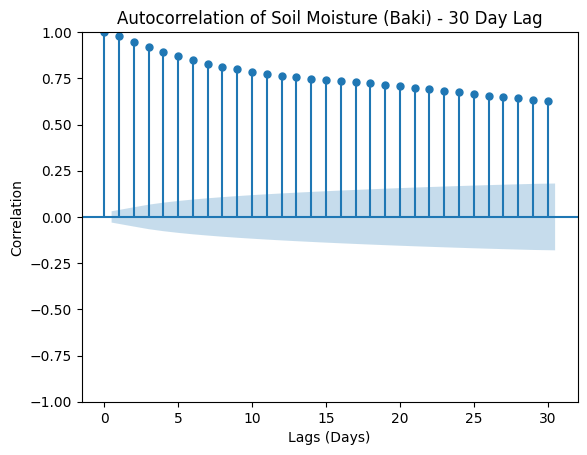

In [5]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# 1. One-Way ANOVA: Temperature across Cities
# Ensure df_all contains all cities from previous steps
model = sm.formula.ols('temperature_2m_mean ~ city', data=df_all).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Results:\n", anova_table)

# 2. Tukey's HSD Post-hoc
tukey = pairwise_tukeyhsd(endog=df_all['temperature_2m_mean'],
                          groups=df_all['city'],
                          alpha=0.05)
print("\nTukey HSD Summary:\n", tukey.summary())

# 3. Autocorrelation Check (ACF) for Soil Moisture
# This helps farmers see how long "memory" lasts in their soil
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plot_acf(df_baki['soil_moisture_0_to_7cm_mean'].dropna(), lags=30)
plt.title("Autocorrelation of Soil Moisture (Baki) - 30 Day Lag")
plt.xlabel("Lags (Days)")
plt.ylabel("Correlation")
plt.show()

In [6]:
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Eta-Squared for ANOVA
model = ols('temperature_2m_mean ~ city', data=df_all).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
eta_sq = anova_table['sum_sq'].iloc[0] / anova_table['sum_sq'].sum()
print(f"Eta-Squared: {eta_sq:.4f}")

# 2. Cohen's d for Two Groups
def calculate_cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

d = calculate_cohen_d(df_all[df_all['city']=='Quba']['temperature_2m_mean'], 
                      df_all[df_all['city']=='Saatli']['temperature_2m_mean'])
print(f"Cohen's d: {d:.4f}")

Eta-Squared: 0.0482
Cohen's d: -0.5593
